In [ ]:
#!pip install otter-grader

# Assignment 3

In [29]:
# Initialize and import
#import otter
#grader = otter.Notebook()
import pandas as pd
bias_pd = pd
import numpy as np
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plots
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

### Assignment instructions

* **How to install 'otter'**: Run `pip install otter-grader` in your Anaconda Command Prompt
* **Otter**: It is an autograder that we will be using for grading your notebooks.
* **grader.check('qn')**: This command runs test cases for nth question `qn` provided to you and displays the result. But these are not the only test cases, these are provided just for your basic testing. There will be some *hidden test cases* on which your answers will be tested as well.
* You are **not** allowed to edit any pre-defined variables and as per the instructions for every question you have to assign your answers to these variables.

### Submission instructions

* Rename your notebook as **YourName_DA3.ipynb**. (e.g. *`JohnDoe_DA3.ipynb`*)
* Download your notebook as a PDF and rename it to **YourName_DA3.pdf**
* Only submit your notebook and PDF in a zip file named **YourName_DA3.zip**

## Dataset
According to the World Health Organization (WHO), strokes are the 2nd leading cause of deaths globally, responsible for approximately 11% of the total deaths. As a researcher, it is important for you to be able to understand what factors impact the likelihood of getting a stroke.

It is believed that smoking and tobacco products in general are a significant contributor. However, a good data scientists uses all available resources at his/her disposal before making any such claims. That is what we will attempt to do in this assignment.

For the sake of simplicitly, we will use a limited-sized publicly-available dataset that provides information regarding 11 clinical features in around 5000 patients, along with whether or not they have experienced any strokes in the past. Each row represents a patient.

In [30]:
# Import dataset
from google.colab import drive
drive.mount('/content/drive',force_remount = True)
path = "/content/drive/MyDrive/ColabNotebooks/DA3/strokes.csv"
df = pd.read_csv(path)
#print(df.head())
#df.info()
df.shape
#df.describe())
#df.isnull().sum()



Mounted at /content/drive


(5109, 12)

## Data summary

Each row in this dataset represents a patient with a specific smoking history. We are interested to see if smoking had any effect on whether or not they experienced a stroke. Several attributes of the individuals are stored in this dataset:

- **id**: the patient's unique ID for the study
- **gender**: whether the patient is a 'Male' or a 'Female'
- **age**: the patient's age at the time of the study
- **hypertension**: 1 if the patient is diagnosed with hypertension, and 0 otherwise
- **heart_disease**: 1 if the patient has a history of heart disease, and 0 otherwise
- **ever_married**: 'Yes' if the patiend has ever been married, and 'No' otherwise
- **work_type**: 'children', 'Govt_jov', 'Never_worked', 'Private' or 'Self-employed'
- **Residence_type**: 'Rural' or 'Urban'
- **avg_glucose_level**: average glucose level in the patient's blood
- **bmi**: the patient's body mass index (BMI)
- **smoking_status**: 'formerly smoked', 'never smoked', 'smokes', or 'Unknown' (this is our treatment variable)
- **stroke**: 1 is the patient has had a stroke, and 0 otherwise (this is our outcome variable)

## Data cleaning

**Question 1**: A patient's `id` is unimportant to us. Drop this column.

In [4]:
# Code here # dropping id column
df.drop(columns=['id'],inplace=True, errors='ignore')
print(df.shape)

# converting all column names to lower
df.columns = df.columns.str.lower()

#converting all row values to lower case
df = df.apply(lambda x: x.astype(str).str.lower())
#df.head()

(5109, 11)


In [ ]:
grader.check("q1")

NameError: name 'grader' is not defined

**Question 2**: There are patients for whom we have no smoking history data (labeled 'Unknown' under `smoking_status`). Drop the rows corresponding to such patients and reset the dataframe index

In [5]:
# Code here #dropping rows 'smoking_status' == unknown
df.drop(df[df['smoking_status']=='unknown'].index,inplace=True)

df.reset_index(drop=True,inplace=True)
print(df.shape)

(3565, 11)


In [ ]:
grader.check("q2")

**Question 3**: We want to be able to work with numeric data. So you will convert the data entries for some columns as described below:

- **gender**: 0 if 'Male' and 1 if 'Female'
- **ever_married**: 0 if 'No', and 1 if 'Yes'
- **work_type**: 0 if 'children', 1 if 'Govt_jov', 2 if 'Never_worked', 3 if 'Private', and 4 if 'Self-employed'
- **Residence_type**: 0 if 'Rural' and 1 if 'Urban'

For simplicity, we will group former and current smokers in the same category.
- **smoking_status**: 1 if 'formerly smoked' or 'smokes' (this will be our treatment group), and 0 if 'never smoked' (this will be our control group)

In [6]:
# Code here #
# converting gender to binary
if not pd.api.types.is_numeric_dtype(df['gender']):
  df['gender'] = df['gender'].apply(lambda x: 0 if x=='male' else 1)

#converting ever_married to binary
if not pd.api.types.is_numeric_dtype(df['ever_married']):
   df['ever_married'] = df['ever_married'].apply(lambda x: 0 if x=='no' else 1)

if not pd.api.types.is_numeric_dtype(df['work_type']):
  def work_categories(category):

    if category=='children':
      return 0
    elif category=='govt_job':
      return 1
    elif category=='never_worked':
      return 2
    elif category=='private':
      return 3
    elif category=='self-employed':
      return 4
    else:
      return pd.NA
df['work_type'] = df['work_type'].apply(work_categories).astype('Int64')

#converting residence_type to binary
if not pd.api.types.is_numeric_dtype(df['residence_type']):
  df['residence_type'] = df['residence_type'].apply(lambda x: 0 if x=='rural' else 1)

# convert smoking_status to binary
# map only if column is non numeric
if not pd.api.types.is_numeric_dtype(df['smoking_status']):
  df['smoking_status'] = df['smoking_status'].apply(lambda x: 1 if (x=='formerly smoked' or x== 'smokes') else 0)

df.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,3,1,228.69,36.6,1,1
1,1,61.0,0,0,1,4,0,202.21,nan,0,1
2,0,80.0,0,1,1,3,0,105.92,32.5,0,1
3,1,49.0,0,0,1,3,1,171.23,34.4,1,1
4,1,79.0,1,0,1,4,0,174.12,24.0,0,1


In [ ]:
grader.check("q3")

**Question 4**: Finally, drop all the rows with NULL values and reset the index

In [7]:
# Code here #

# dropping all rows with NULL values and resetting index
df = df.replace({'nan': pd.NA, 'na': pd.NA, 'none': pd.NA, '': pd.NA})   # as some null values are 'nan' . its handling these as strings. so replacing back to NA
df = df.dropna().reset_index(drop=True)

print(df.shape)

(3425, 11)


In [ ]:
grader.check("q4")

## Exploratory Data Analysis

We are curious to see how different groups of patients react to the treatment (smoking status). The `smoking_status` variable is 1 if the individual is a smoker.

**Question 5:**

a) Complete the function given below. Given a column name and dataframe, `treatment_plot` should plot the estimated average treatment effect for **all** groups of that column variable.  *For reference, refer to q5.png, which is what should be output if you input 'gender' (you can have minor differences like colors, but the axis should be the same).*

b) What do you observe in your treatment plot for the column `gender`? Write your answer as a comment.

In [8]:
#df['stroke'] = df['stroke'].astype(int)
#df.drop(columns=['stroke#'],inplace=True)
#print(df['gender'].value_counts())
#print(df['smoking_status'].value_counts())
#print(df['stroke'].value_counts())
#print(df.info())

gender_map = {0:'Male',1:'Female'}
df['gender_label'] = df['gender'].map(gender_map)

smoke_map = {0:'Non Smoker',1:'smoker'} # formerly smokes, never smokes
df['smoking_status_label'] = df['smoking_status'].map(smoke_map)

df['stroke'] = pd.to_numeric(df['stroke'], errors='coerce')

group = df.groupby(['gender_label','smoking_status_label'])['stroke'].mean().unstack()
print(group)

def treatment_plot(data, col, x_labels=None):
  group = df.groupby(['gender','smoking_status'])['stroke'].mean().unstack()
  group.columns = ['Non-Smoker', 'Smoker']

  gender_map = {0:'Male',1:'Female'}
  df['gender_label'] = df['gender'].map(gender_map)

  # plot the data
  plt.figure(figsize=(10,6))
  group.plot(kind='bar',color = ['#FF7F50', '#2E8B57'])

  plt.title('Average Treatment Effect')
  plt.xlabel('gender')
  plt.ylabel('stroke')

  if x_labels:                               # optional manual labels
    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=0)
    plt.legend(title='smoking status')

  plt.show()


smoking_status_label  Non Smoker    smoker
gender_label                              
Female                  0.049044  0.052095
Male                    0.038521  0.072464


<Figure size 1000x600 with 0 Axes>

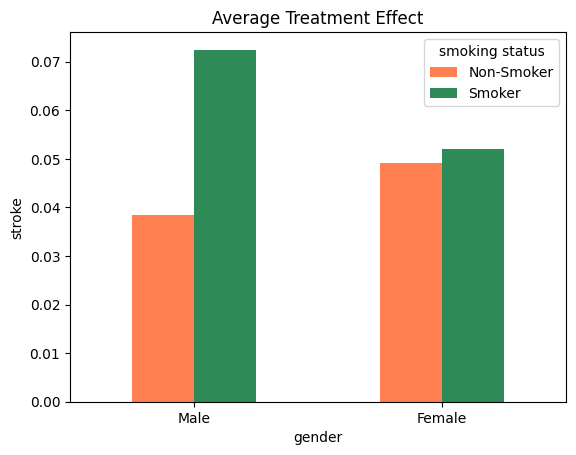

In [ ]:
treatment_plot(data= df, col='gender', x_labels=['Male','Female'])

#print(df['gender'].unique())
#df.info()

**Answer**:This graph clearly shows that :

*   Smokers have higher stroke rate as compared to non smokers for both males and females
*   Difference is much larger for males, showing that male who smoke have much higher stroke rate as compared to famles


**Question 6:**

a) Plot a correlation heatmap for this dataset (it should be a color coded graph indicating correlation values for each of the columns against every other column).

b) Comment on any notable correlations. For any of these pairs, answer the following questions: Are they causally related? If so, is their causal relationship direct or indirect? Name any confounding variables you suspect. If you do not think they are causally related, comment why.

Note: You will be graded on how critically you have commented, not how much you write. So keep your answers crisp and to the point, but also think deeply.

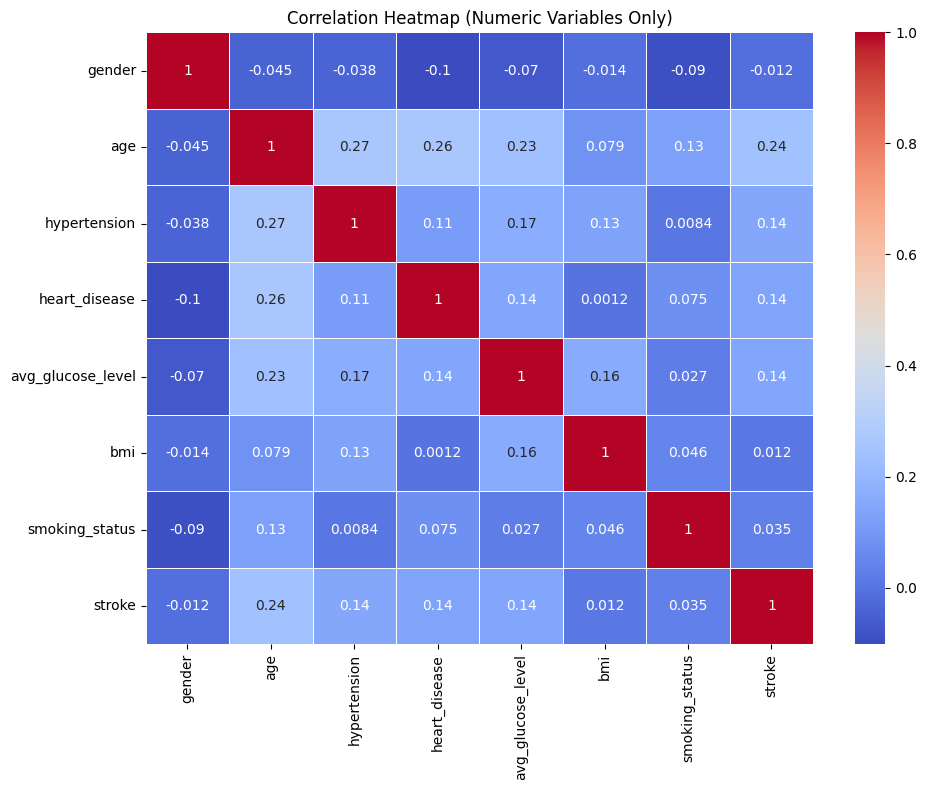

In [9]:
# Code here #

num_columns = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke','gender','smoking_status']
for col in num_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# select numeric data only
numeric_df = df.select_dtypes(include=['int64', 'float64', 'Int64', 'boolean'])

# exclude unwanted columns (if any exist numerically)
exclude = ['ever_married', 'residence_type', 'work_type']
numeric_df = numeric_df.drop(columns=exclude, errors='ignore')

# compute correlation
corr = numeric_df.corr()

# plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Variables Only)')
plt.tight_layout()
plt.show()

Correlation heatmap shows correlation coefficients between pairs of numeric values.

**Guidelines to Read Heatmap:**

•	Values range from -1 to +1

•	+1  Strong positive correlation. As 1 variable increases, other one also increases proportionally.

•	0  No correlation. No linear relationship between two variables

•	-1  Strong negative correlation between variables. As 1 increases other one decreases

•	Warm Colors( red/orange)  positive correlation

•	Cool Colors (blues)  Negative correlation

•	White/ Neutral Colors  Weak or no correlation

•	Intensity (darkness) of colors show strength. The darker the color, stronger is correlation.


**Strength of Relationship:**

•	Strong   >   0.7   <   -0.7  . Possibility of redundancy

•	Moderate   0.3 - 0.7  0r  -0.3 – (-0.7)   Possible Linear trend worth testing

•	Weak  < 0.3 or > -0.3    Not much linear relationship.


**Point to Remember:**

Correlation is not always equal to Causation.  High correlation doesn’t always mean one variable causes the other one, there may be confounding variables.

**Strokes Dataset Heatmap Analysis:**

•	Age  < -- >  Stroke   ~ 0.24  -- >

•	 Heart Disease  < -- >   Stroke    ~ 0.14

•	Avg Glucose < -- > Stroke  ~  0.14

•	Smoking < -- >  Stroke  ~ 0.035

•	Age < -- > Hypertension  ~ 0.27

•	Age < -- > Heart Disease  ~ 0.26

•	Age < -- > BMI  ~ 0.079

•	Hypertension < -- >  Heart Disease  ~ 0.11

•	Avg Glucose  < -- > BMI   ~ 0.16

•	BMI < -- > Hypertension  ~0.13


 **We can conclude from heat map:**

•	**Age is correlated to stroke**. With increasing age chances of stroke rise.  Age is likely direct causal to stroke. Although other variables like hypertension and heart disease are also adding up to the chances. These could be the confounders as with age these increase chances of stroke.



•	**Hypertension and Heart disease** are also correlated and have direct causal effect. There can be confounders also as Age, BMI, Smoking Status. All these variables add up lead towards stroke.


•	**Age and Hypertension** are related to each her directly. These variables have weak but direct causal effects
•	BMI and Hypertension have weak correlation and not direct.  Blood sugar and age can be confounders and can lead to stroke finally.


•	**Smoking and Heart Disease** are weaky corelated according to heatmap. These variables have kind of direct causal effect but other confounders are also present like age and hypertension which ultimately lead to stroke.



•	**Gender and Smoking**. Males have higher smoking rates. These don’t have direct causal effect. Most likely due to social reasons.



Overall correlation in heatmap is weak towards moderate.

Only **age -- > hypertension -- > stroke represent true causal effect**. Others reflect shared confounders. So correlation strength does not mean causality always.  Causal inference requires adjusting for these confounding variables. Most variables have weak correlation with stroke. so no variable in the dataset is strong predictor of stroke.    


## The Effect of Smoking (Treatment)

**Question 7:**

a) Find the overall estimated average treatment effect (under certain assumptions) of smoking. Store it in the variable `estimated_ATE`.
Note: Your test case may pass even if your value has the wrong sign.

b) Is your result positive or negative? What do the sign (+ve or -ve) and magnitude of your result tell you about the effect of smoking? Write your answer as a comment.

In [10]:
## Code here #
#print(df.info())

# converting stroke to number type
df['stroke'] = pd.to_numeric(df['stroke'], errors='coerce')

count_0 = (df['stroke']==0).sum()
count_1 = (df['stroke']==1).sum()

print("No Stroke:", count_0)
print("Stroke:", count_1)

estimated_ATE = df[df['smoking_status'] == 1]['stroke'].mean() - df[df['smoking_status'] == 0]['stroke'].mean()
estimated_ATE = round(estimated_ATE,6)
print("Estimated ATE is : ",estimated_ATE)
#df.info()

No Stroke: 3245
Stroke: 180
Estimated ATE is :  0.015674


 **(b)**

 **Positive & Negative Sign of ATE and Magnitude:**

 In Average Treatment Effect (ATE)  calculation , positive or negative  sign shows the direction of effect of the treatment.

•	Positive (+) ATE shows that on average the group that received treatment has a higher outcome value as compared to that control group. It shows that treatment has beneficial effects if a higher outcome(e.g.; increased risk of stroke) is desired or an adverse effect if higher outcome is undesirable.

•	Negative (-) ATE shows that on average the group that received treatment has lower effects as compared to the control group. It means treatment has beneficial  effects if a lower outcome is desired (e.g.; decreased risk of stroke) or adverse effect if a lower outcome is undesirable.

•	An ATE of zero (0) would suggest that treatment has no effect on outcomes.

**ATE Outcome and magnitude in Strokes Dataset:**

***Estimated ATE is positive*** in given dataset showing that average probability of having stroke is higher in smokers than non-smokers. **


 Positive sign indicates that smoking is associated with increased risk of stroke**.



**The magnitude of ATE (1.57 %) shows that its not very significant difference in smokers and non smokers in a large dataset**.

Therefore, it exists , though small but still not very large in raw dataset.
Smoking alone is not directly causing stroke but confounding factors like age, hypertension, heart disease and glucose levels, influence the stroke risk.


c) Does this value reflect the actual accurate treatment effect (effect of smoking) in our population? If not, under what assumptions will this be an accurate representation of the actual ATE?

**Answer**:
This ATE does not represent accurate treatment effct (effect of smoking in our population). There are many other factors as well which are effecting actual accurate treatment effect, which include age, hypertension, heart desease and glucose levels.Smokers and non smokers differ those characteristics. These differences create biases in above calculated ATE.



---



In [ ]:
grader.check("q7")

**Question 8**: Does this estimated average treatment effect make sense to you or are we missing something? Explore the data further and look at the distribution of different groups of patients (i.e., patients having different values for different attributes) across the treatment and control groups. Comment on how this distribution **may** impact your observed ATE.

In [11]:
# write any code you need

df.groupby('gender').agg(
    total_people = ('age', 'count'),
    avg_age = ('age', 'mean'),
    stroke_percent = ('stroke',  lambda x: x.mean() * 100),
    heart_disease_percent = ('heart_disease', lambda x: x.mean() * 100),
    hypertension_percent = ('hypertension', lambda x: x.mean() * 100),
    smokers_percent = ('smoking_status', lambda x: x.mean() * 100)
).round(4)

,total_people,avg_age,stroke_percent,heart_disease_percent,hypertension_percent,smokers_percent
gender,,,,,,
0,1339,49.7013,5.6012,9.0366,13.4429,51.5310
1,2086,47.9794,5.0336,4.0748,10.9300,42.3298


**Answer**:
We are missing confounding factors here. We see that there can be imbalance in control and treatment groups. Some of issues we can see from table:, which **may impact our observed ATE**

•	Total number of people is not equally distributed in males and females. So ATE can be biased

•	Average age also has difference, not equally distributed. ATE may be biased because age effects the outcome i.e. stroke risk.

•	Herat diseases and hypertension values are also showing that there can be biased ATE. Because ATE cab be higher if more people in treatment group have hypertension and heart diseases.

•	Gender imbalance could also be reason for biased ATE. Because baseline health track can be different for males and females.

•	Smokers also make difference in average ATE. As if more smokers would be in treatment group this will effect the outcome i.e. stroke ratio.


**Question 9a**: Now write code to find the estimated treatment effect separately within the different groups you explored above. What do your observations tell you? Do you think Simpson's Paradox can be seen manifesting in these observations? If you do observe Simpson's paradox, adjust for these covariates and report the conditional average treatment effect.

In [12]:
# Code here #
#   start mappings
gender_map = {0: 'Male',1:'Female'}
df['gender_label'] = df['gender'].map(gender_map)

smoke_map = {0:'Non Smoker',1:'Smoker'}# formerly smokes, never smokes
df['smoking_status_label'] = df['smoking_status'].map(smoke_map)

stroke_map = {0:'No',1:'Yes'}
df['stroke_label'] = df['stroke'].map(stroke_map)

stroke_map = {0:'No',1:'Yes'}
df['stroke_label'] = df['stroke'].map(stroke_map)

hypertension_map = {0:'No',1:'Yes'}
df['hypertension_label'] = df['hypertension'].map(hypertension_map)

heart_disease_map = {0:'No',1:'Yes'}
df['heart_disease_label'] = df['heart_disease'].map(heart_disease_map)

work_type_map = {0:'Children',1:'Govt Job', 2:'Never Worked', 3:'Private', 4:'Self Employed',}
df['work_type_label'] = df['work_type'].map(work_type_map)

residence_type_map = {0:'Rural',1:'Urban'}
df['residence_type_label'] = df['residence_type'].map(residence_type_map)
#  End mappings

# making sure columns are numeric
df['stroke'] = pd.to_numeric(df['stroke'], errors='coerce')
df['hypertension'] = pd.to_numeric(df['hypertension'], errors='coerce')
df['hypertension'] = pd.to_numeric(df['hypertension'], errors='coerce')
df['heart_disease'] = pd.to_numeric(df['heart_disease'], errors='coerce')
df['work_type'] = pd.to_numeric(df['work_type'], errors='coerce')
df['residence_type'] = pd.to_numeric(df['residence_type'], errors='coerce')

group = df.groupby(['gender_label','smoking_status_label'])['stroke'].mean().unstack()

group['Gender Wise ATE'] = group['Smoker'] - group['Non Smoker']

print(group)

print("\n")

group = df.groupby(['hypertension_label','smoking_status_label'])['stroke'].mean().unstack()
group['hyprtension ATE'] = group['Smoker'] - group['Non Smoker']
print(group)
print("\n")

group = df.groupby(['heart_disease_label','smoking_status_label'])['stroke'].mean().unstack()
group['heart_diseas ATE: '] = group['Smoker'] - group['Non Smoker']
print(group)
print("\n")

group = df.groupby(['work_type_label','smoking_status_label'])['stroke'].mean().unstack()
group['work Type ATE'] = group['Smoker'] - group['Non Smoker']
print(group)
print("\n")

group = df.groupby(['residence_type_label','smoking_status_label'])['stroke'].mean().unstack()
group['Rural/Urban ATE'] = group['Smoker'] - group['Non Smoker']
print(group)


smoking_status_label  Non Smoker    Smoker  Gender Wise ATE
gender_label                                               
Female                  0.049044  0.052095         0.003051
Male                    0.038521  0.072464         0.033943


smoking_status_label  Non Smoker    Smoker  hyprtension ATE
hypertension_label                                         
No                      0.033007  0.049964         0.016956
Yes                     0.138889  0.140625         0.001736


smoking_status_label  Non Smoker    Smoker  heart_diseas ATE: 
heart_disease_label                                           
No                      0.041220  0.049033            0.007813
Yes                     0.135802  0.200000            0.064198


smoking_status_label  Non Smoker    Smoker  work Type ATE
work_type_label                                          
Children                0.000000  0.000000       0.000000
Govt Job                0.040000  0.050209       0.010209
Never Worked            0.0000

**Answer**:
**Simpson's Paradox**

**Definition:** (copied definition)

"Simpson’s Paradox occurs when a trend or association that appears in several different groups of data reverses or disappears when the data are combined (aggregated).

It reveals how aggregating data can distort relationships due to the presence of a confounding variable — one that influences both the independent variable (X) and the dependent variable (Y)."



in Q.7 we calculated **population average effect which was 1.6 %**


We explored different groups to find ATE and reached at results:

•	Group of males and females who smokers and non smokers ATE is .003  for females and 0.033 for males. Which means effect of smoking on females is very tiny, only **0.3 %** points while in males its **~ 3.4 %** points. So population average effect is ~1.6 but when we stratify we find very small effect on females and strong positive effect on males. This is classic sign of Simpson’s paradox. The population average effect ( ~1.6 %) is hiding big difference between subgroups.

•	If we stratify our data according to hypertension with smokers or non smokers we get ATE for people (having no hypertension) ~ 1.6 % and ~ 0.017 % for people with hypertension as compared to population average effect of  ~ 1.6%.  I see Simpson’s Paradox phenomena in this case. As no bog difference is hiding in it.

•	If we stratify our population according to heart disease with people who smoke or don’t smoke we see ATE for people with no heart disease is 0.7 and for people with heart disease its 6.4.  Simpson’s Paradox is noticeable here.

•	Other groups like with residence or work type were also explored and we can see the difference in population average effect and ATE in different groups.




**Question 9b**: Now we want to explore the effect of conditioning on certain attributes on the overall estimated ATE. Condition on at least 3 attributes from the dataset *one by one* to report how the estimated ATE changes (this will require trial and error). For example, in the first step, condition on attribute *x*. In the next step, condition on some *x* and *y* together, and so on.

Report on your observations. How does the ATE change with every step? What does this tell you about the effect of these attributes on the probability of getting a stroke among smokers and non-smokers.

Hint: refer to lecture slides to see how you can adjust for covariates to find a conditional ATE.

In [13]:
# Code here #
# as we calculated unconditional estimated ATE earlier

estimated_ATE0 = df[df['smoking_status'] == 1]['stroke'].mean() - df[df['smoking_status'] == 0]['stroke'].mean()
estimated_ATE0 = round(estimated_ATE0,6)
print("Estimated ATE0 is : ",estimated_ATE0)

estimated_ATE1 = (
    df.groupby('gender')
      .apply(lambda x:
        x[x['smoking_status'] == 1]['stroke'].mean() -
        x[x['smoking_status'] == 0]['stroke'].mean()
            )
      .mean()
              )
estimated_ATE1 = round(estimated_ATE1,6)
print("Estimated ATE1 is : ", estimated_ATE1)

estimated_ATE2 = (
    df.groupby(['gender','heart_disease'], group_keys = False)
      .apply(lambda x:
        x[x['smoking_status'] == 1]['stroke'].mean() -
        x[x['smoking_status'] == 0]['stroke'].mean()
            )
      .mean()
              )
# Estimated ETA with one condition on gender
estimated_ATE2 = round(estimated_ATE2,6)
print("Estimated ATE2 is : ", estimated_ATE2)

estimated_ATE3 = (
    df.groupby(['gender','heart_disease','hypertension'], group_keys = False)
      .apply(lambda x:
        x[x['smoking_status'] == 1]['stroke'].mean() -
        x[x['smoking_status'] == 0]['stroke'].mean()
            )
      .mean()
              )
# Estimated ETA with one condition on gender
estimated_ATE3 = round(estimated_ATE3,6)
print("Estimated ATE3 is : ", estimated_ATE3)

estimated_ATE4 = (
    df.groupby(['gender','heart_disease','hypertension','residence_type'], group_keys = False)
      .apply(lambda x:
        x[x['smoking_status'] == 1]['stroke'].mean() -
        x[x['smoking_status'] == 0]['stroke'].mean()
            )
      .mean()
              )
# Estimated ETA with one condition on gender
estimated_ATE4 = round(estimated_ATE4,6)
print("Estimated ATE4 is : ", estimated_ATE4)



Estimated ATE0 is :  0.015674
Estimated ATE1 is :  0.018497
Estimated ATE2 is :  0.033717
Estimated ATE3 is :  0.034033
Estimated ATE4 is :  0.042371


/tmp/ipython-input-3247263481.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:
/tmp/ipython-input-3247263481.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:
/tmp/ipython-input-3247263481.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excl

**Answer**:

From above calculated ATEs we can see that:

With no conditioning  : 1.56

With condition on gender : 1.85

With condition on gender and heart disease : 3.37

With condition on gender, heart disease and hypertension : 3.40

With condition on gender, heart disease, hypertension and residence type : 4.24

Its obvious that as we condition on more covariates, Its magnitude changes. Unadjusted ATE (without any condition) was biased and misleading. After adjusting the magnitude of ATE becomes more stable. Initial ATE was due to confounders.

variables like gender, hypertension, heart disease and living type can effect the probability of stroke. After adjusting we can get more realistic ATE.

**According to Simpson's Paradox " Overall ATE hides different sub groups patterns", which can be seen here clearly.**


**Question 10:**

a) Calculate the p-value for the treatment and store it in `p_value`.

b) Comment on the statistical significance of your result. What does this p-value say about smoking and strokes? Clearly state your null and alternative hypotheses and the significance level you have chosen for your p-value. Should you reject the null hypothesis?

Note: You are allowed to use scipy for calculating the p-value.

In [27]:
# Code here # finding p value
#Treatment = Smokers (1),  Control Group = Non Smokers (0)
treat_group = df[df['smoking_status'] == 1]['stroke']

control_group = df[df['smoking_status'] == 0]['stroke']

# two-sample t-test (Welch's by default if equal_var=False)
stat, p_value = ttest_ind(treat_group, control_group, equal_var= False)
print("p-value is : ", round(p_value,6))
print("t-stat value : ", round(stat,6))


p-value is :  0.042845
t-stat value :  2.026043


**Answer**:

**Steps to Reach to Decision:**

•	Formulate H0: No effect/difference

•	Formulate H1 : There is an effect

•	Set alpha (usually 0.05) : 5% cutoff for rejecting H0

•	Calculate t-statistics: Standard measure of difference , Higher = stronger evidence

•	Find p-value: Probability of observing data under H0 , Smaller value = Stronger evidence

•	Decision Rule is: Compare p with alpha, if p  <  alpha -- > Reject H0



**Formulation for Decision According to Strokes Dataset:**

•	**Null Hypothesis (H0) : Smoking has no effect on the probability of stroke**

In statistical terms:

H0 : µ(smokers) = µ(non-smokers)

Or since stroke is binary (0/1) :

H0 : P(stroke = 1 | smokers) = P(stroke =1 | non-smokers)



**•	Alternate Hypothesis (H1) : Smoking has effect on probability of stroke**

In statistical terms

H1 : µ(smokers) ≠ µ(non-smokers)

OR

H1 : P(Stroke =1 | smokers) ≠ P(Stroke =1 | non-smokers)

•	α  0.05

•	t-stat = 2.026

•	p-value = 0.043

•	Decision : Since **p <  0.05**

Therefore we **reject Null Hypothesis**, which states that Smoking has no effect on the probability of stroke.

**Conclusion is:  
There is statistically significant evidence that smoking effects probability of stroke in the dataset. and positive t-value suggets that smokers have higher stroke risk.**




In [ ]:
grader.check("q10")

We now introduce a biased sample of our dataset.

In [19]:

from google.colab import drive
drive.mount('/content/drive',force_remount = True)

path = "/content/drive/MyDrive/ColabNotebooks/DA3/strokes_bias.csv"
#!ls "/content/drive/MyDrive/ColabNotebooks/DA3/Copy of Copy of strokes_bias.csv"

bias_df = pd.read_csv(path)
bias_df.head()#
#bias_df.info()
print(bias_df.shape)
#bias_df.describe()
#print(bias_df.isnull().sum())

Mounted at /content/drive
(5109, 12)


**Question 11:**

a) Clean this data as you did for the previous dataset.

b) Plot estimated average treatment plots for all groups of each of the columns of `bias_df` (except the column `stroke` and any columns that have `float` type data). Hint: Use a loop and the function you made earlier.

In [20]:

# Code here # dropping id column
bias_df.drop(columns=['id'],inplace=True,  errors='ignore')
#print(bias_df.shape)

bias_df.columns = bias_df.columns.str.lower()

obj_cols = bias_df.select_dtypes(include='object').columns
bias_df[obj_cols] = bias_df[obj_cols].apply(lambda s: s.str.lower().str.strip())

# as my null values are 'nan' . its handling these as strings. so replacing back to NA
bias_df = bias_df.replace({'nan': pd.NA, 'na': pd.NA, 'none': pd.NA, '': pd.NA})

#dropping unknown smoking status and resetting the index
bias_df.drop(bias_df[bias_df['smoking_status']=='unknown'].index, inplace=True)

# converting stroke to number type
bias_df['stroke'] = pd.to_numeric(bias_df['stroke'], errors='coerce')

#resetting index
bias_df.reset_index(drop=True,inplace=True)

# converting gender to binary
if not bias_pd.api.types.is_numeric_dtype(bias_df['gender']):
  bias_df['gender'] = bias_df['gender'].apply(lambda x: 0 if x=='male' else 1)

#converting ever_married to binary
if not bias_pd.api.types.is_numeric_dtype(bias_df['ever_married']):
   bias_df['ever_married'] = bias_df['ever_married'].apply(lambda x: 0 if x=='no' else 1)

def work_categories(category):

  if category=='children':
    return 0
  elif category=='govt_job':
    return 1
  elif category=='never_worked':
    return 2
  elif category=='private':
    return 3
  elif category=='self-employed':
    return 4

bias_df['work_type'] = bias_df['work_type'].apply(work_categories).astype('Int64')

#converting residence_type to binary
if not bias_pd.api.types.is_numeric_dtype(bias_df['residence_type']):
  bias_df['residence_type'] = bias_df['residence_type'].apply(lambda x: 0 if x=='rural' else 1)

# convert smoking_status to binary numeric
bias_df['smoking_status'] = bias_df['smoking_status'].apply(
    lambda x: 1 if x in ['formerly smoked','smokes'] else 0
).astype(int)

# dropping all rows with NULL values and resetting index
bias_df = bias_df.dropna().reset_index(drop=True)

print(bias_df.shape)
bias_df.head()
#bias_df.info()


(3425, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,60.0,1,0,1,1,0,100.20,28.5,1,0
1,1,42.0,0,1,1,1,1,226.93,34.2,1,0
2,0,54.0,1,0,1,3,0,116.44,24.5,0,0
3,1,58.0,0,0,1,3,0,59.86,28.0,1,0
4,1,36.0,0,0,1,3,0,146.61,39.6,0,0


Columns used for ATE plots: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type']

=== ATE by gender ===


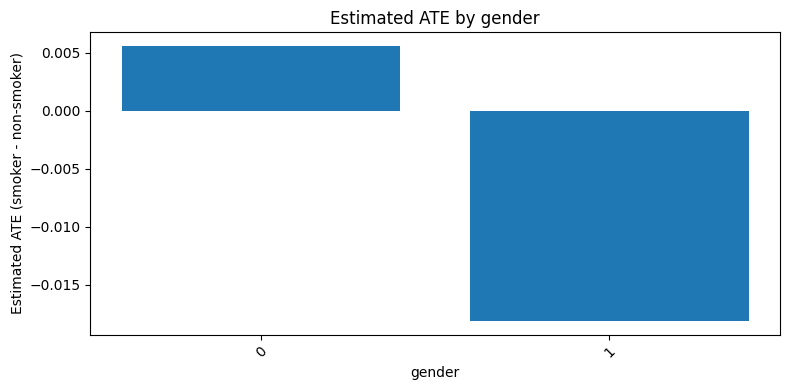


=== ATE by hypertension ===


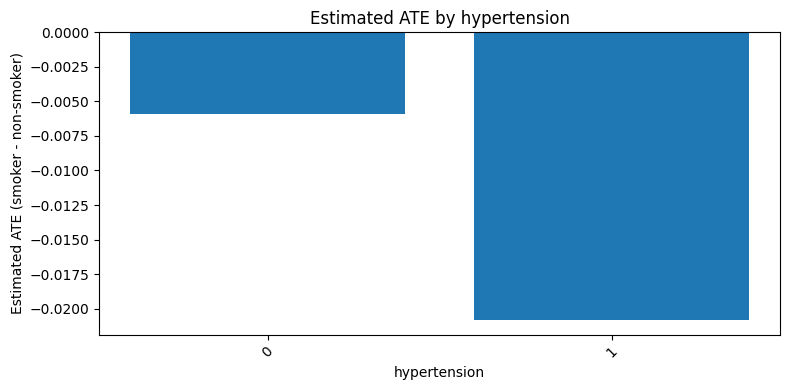


=== ATE by heart_disease ===


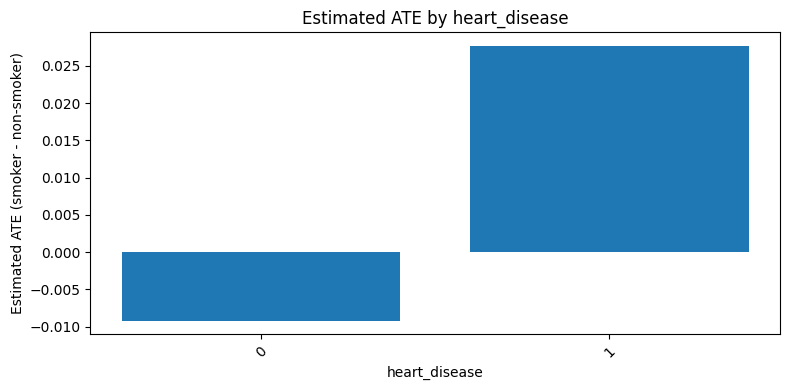


=== ATE by ever_married ===


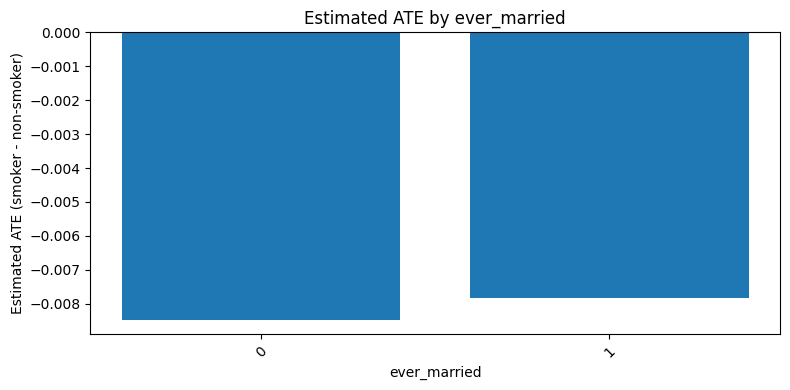


=== ATE by work_type ===


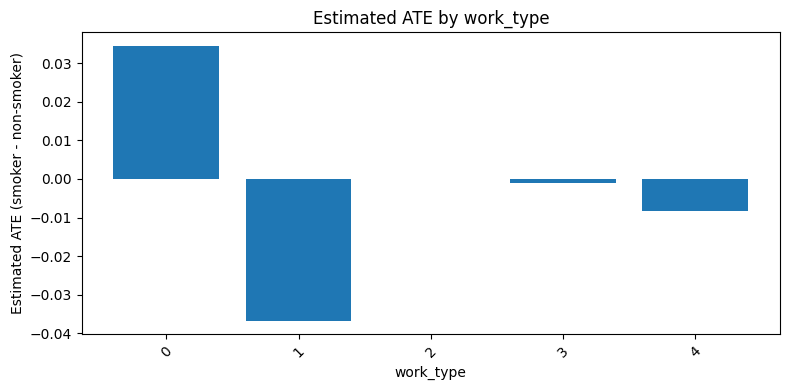


=== ATE by residence_type ===


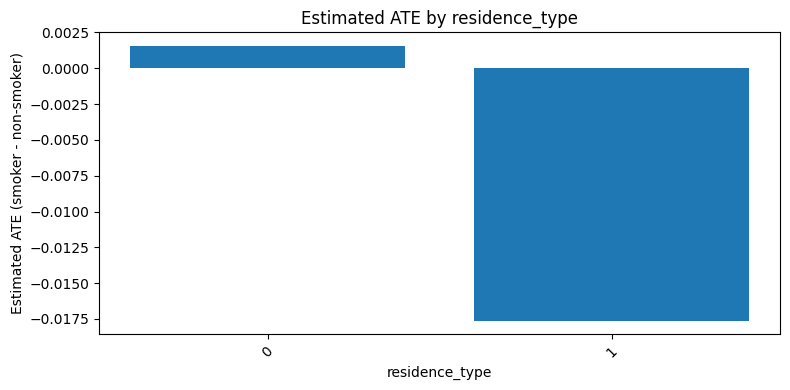

In [32]:
# Answer Question 11 (b):
#Plot estimated average treatment plots for all groups of each of the columns of bias_df
# (except the column stroke and any columns that have float type data).
# Hint: Use a loop and the function you made earlier.

#function to plot ATE by groups of a single column
def treatment_plot(df, group_col, treatment_col = 'smoking_status', target_col = 'stroke'):

  plot_cols = df[[df,group_col, treatment_col, target_col]].dropna()

  group = plot_cols.groupby([group_col, treatment_col])[target_col].mean().unstack()

  group['ATE'] = group[1] - group[0]

  plt.figure(figsize=(10,6))

  plt.bar(group.index.astype(str), group['ATE'])

  plt.xlabel(group_col)
  plt.ylabel('Estimated ATE (smokers, non-smokers)')
  plt.title(f'Estimated Average Treatment Effect by {group_col}')
  plt.tight_layout()
  plt.show()

import matplotlib.pyplot as plt
import pandas as pd

def treatment_plot(df, group_col, treatment_col='smoking_status', target_col='stroke'):

    plot_df = df[[group_col, treatment_col, target_col]].dropna()

    # Make sure treatment is numeric 0/1
    plot_df[treatment_col] = pd.to_numeric(plot_df[treatment_col], errors='coerce')

    # Group by group_col and treatment_col
    group = plot_df.groupby([group_col, treatment_col])[target_col].mean().unstack()

    # Ensure both 0 and 1 exist as columns
    for t in [0, 1]:
        if t not in group.columns:
            group[t] = float('nan')

    group['ATE'] = group[1] - group[0]

    # Plot
    plt.figure(figsize=(8, 4))
    plt.bar(group.index.astype(str), group['ATE'])
    plt.xlabel(group_col)
    plt.ylabel('Estimated ATE (smoker - non-smoker)')
    plt.title(f'Estimated ATE by {group_col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Build list of columns to plot
cols_to_plot = []
for col in bias_df.columns:
    # skip outcome
    if col == 'stroke':
        continue
    # skip float-type columns
    if pd.api.types.is_float_dtype(bias_df[col]):
        continue
    # skip treatment itself
    if col == 'smoking_status':
        continue
    cols_to_plot.append(col)

print("Columns used for ATE plots:", cols_to_plot)

# Plot for each column
for col in cols_to_plot:
    print(f"\n=== ATE by {col} ===")
    treatment_plot(bias_df, group_col=col)


In [ ]:
grader.check("q11")

**Question 12:** Find the estimated average treatment effect for this dataset and store it in `bias_ATE`.

In [21]:
# Code here #
bias_ATE = bias_df[bias_df['smoking_status']==1]['stroke'].mean() - \
           bias_df[bias_df['smoking_status']==0]['stroke'].mean()
print("biased ATE : ",round(bias_ATE,6))


biased ATE :  -0.007779


In [ ]:
grader.check("q12")

**Question 13**: What is the difference in the estimated treatment effect between the real and biased datasets? Store your answer in `bias_magnitude`

In [28]:
# Code here #
bias_magnitude = round(estimated_ATE - bias_ATE,6)
print("bias_magnitude : ", bias_magnitude)

bias_magnitude :  0.023453


In [ ]:
grader.check("q13")

In [ ]:
grader.check_all()